# IPL  Match Optimization analysis
# Objectives:
Analyse the factors affecting IPL ticket sales and optimize the match scheduling

In [2]:
import pandas as pd
df=pd.read_csv("../data/ipl_data.csv")
df.head()


,team1,team2,popularity_team1,popularity_team2,stadium,capacity,is_weekend,good_weather,tickets_sold
0,PBKS,RCB,5,5,Narendra Modi Stadium,132000,1,0,84980
1,KKR,RR,6,9,Chinnaswamy,40000,0,0,40000
2,GT,PBKS,7,9,Chinnaswamy,40000,0,1,40000
3,LSG,RR,10,9,Wankhede,33000,1,0,33000
4,GT,RCB,10,6,Eden Gardens,66000,0,0,58823


# Data Cleaning and Validation
cheecking dataset quality by verifying missing values, duplicate rows, and correct data types



In [3]:
df.isnull().sum()
df.duplicated().sum()
df.dtypes

team1                 str
team2                 str
popularity_team1    int64
popularity_team2    int64
stadium               str
capacity            int64
is_weekend          int64
good_weather        int64
tickets_sold        int64
dtype: object

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   team1             200 non-null    str  
 1   team2             200 non-null    str  
 2   popularity_team1  200 non-null    int64
 3   popularity_team2  200 non-null    int64
 4   stadium           200 non-null    str  
 5   capacity          200 non-null    int64
 6   is_weekend        200 non-null    int64
 7   good_weather      200 non-null    int64
 8   tickets_sold      200 non-null    int64
dtypes: int64(6), str(3)
memory usage: 14.2 KB


In [5]:
df.describe()

,popularity_team1,popularity_team2,capacity,is_weekend,good_weather,tickets_sold
count,200.000000,200.000000,200.0000,200.000000,200.000000,200.000000
mean,7.760000,7.530000,60990.0000,0.425000,0.465000,51743.005000
std,1.722567,1.668237,35990.2262,0.495584,0.500025,20295.041879
min,5.000000,5.000000,33000.0000,0.000000,0.000000,33000.000000
25%,6.000000,6.000000,38000.0000,0.000000,0.000000,38000.000000
50%,8.000000,8.000000,40000.0000,0.000000,0.000000,40000.000000
75%,9.000000,9.000000,66000.0000,1.000000,1.000000,66000.000000
max,10.000000,10.000000,132000.0000,1.000000,1.000000,106628.000000


In [6]:
df.columns

Index(['team1', 'team2', 'popularity_team1', 'popularity_team2', 'stadium',
       'capacity', 'is_weekend', 'good_weather', 'tickets_sold'],
      dtype='str')

# Exploratory Data Analysis
Analyzing how different factors such as weekends, weather, popularity, and stadium choice affect IPL ticket sales.

In [7]:
df.groupby("is_weekend")["tickets_sold"].mean()

is_weekend
0    50343.391304
1    53636.600000
Name: tickets_sold, dtype: float64

In [8]:
df.groupby("good_weather")["tickets_sold"].mean()

good_weather
0    52092.570093
1    51340.817204
Name: tickets_sold, dtype: float64

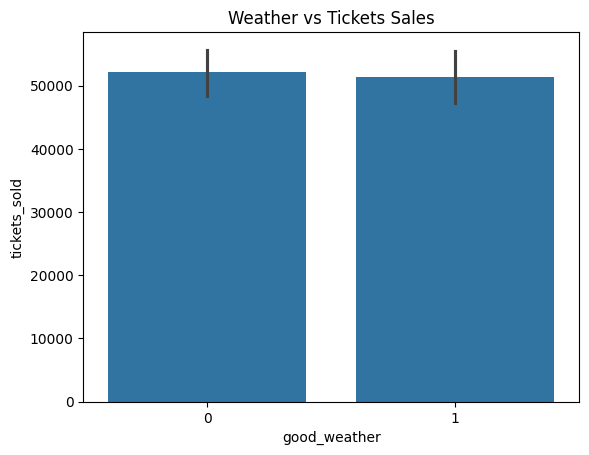

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x="good_weather", y="tickets_sold", data=df)
plt.title("Weather vs Tickets Sales")
plt.show()

In [10]:
df["total_popularity"]=df["popularity_team1"]+df["popularity_team2"]

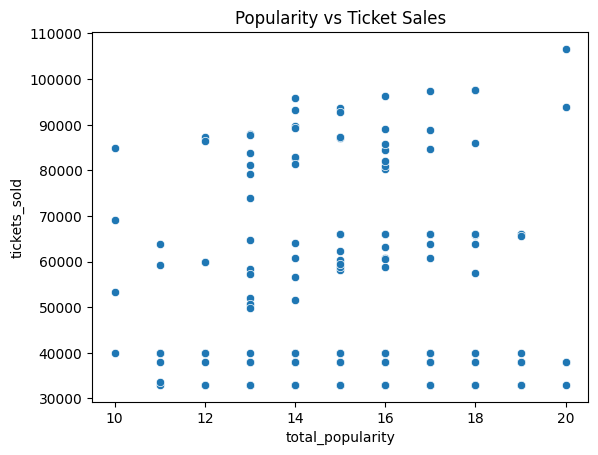

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x="total_popularity",y="tickets_sold",data=df)
plt.title("Popularity vs Ticket Sales")
plt.show()

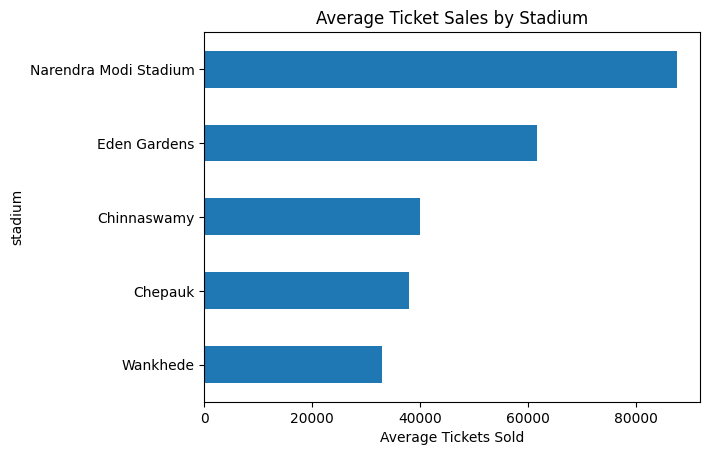

In [12]:
stadium_sales=df.groupby("stadium")["tickets_sold"].mean().sort_values()
stadium_sales.plot(kind="barh")
plt.title("Average Ticket Sales by Stadium")
plt.xlabel("Average Tickets Sold")
plt.show()

# Predictive Modeling
Using linear regression to estimate ticket sales.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x=df[["popularity_team1","popularity_team2","good_weather","is_weekend"]]
y=df["tickets_sold"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
print("model trained successfully!")


model trained successfully!


In [14]:
sample_prediction=model.predict([[9,8,1,1]])
print("predicted ticket sales for sample match:",sample_prediction[0])


predicted ticket sales for sample match: 50850.11221121187


c:\Users\krupa\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


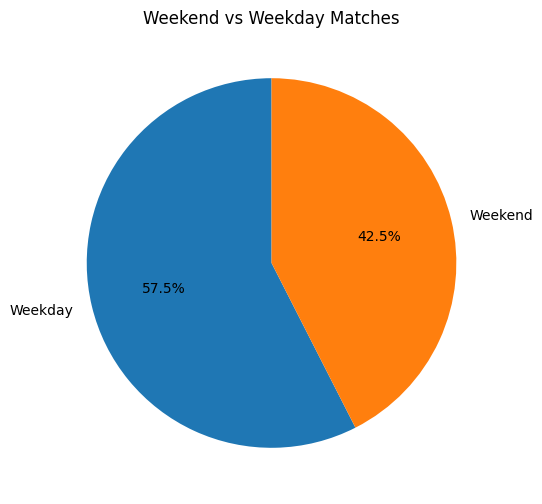

In [ ]:
weekend_counts=df["is_weekend"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
weekend_counts, labels=["Weekday","Weekend"], autopct="%1.1f%%", startangle=90
)
plt.title("Weekend vs Weekday Matches")
plt.show()


# Project Insights
# 1. Weekend Matches Improve Attendance
     The analysis indicates that match timing influences ticket sales. Weekend matches generally attract higher audience turnout because spectators are more available to attend during holidays and leisure time.

# 2. Team Popularity Strongly Drives Demand
    A positive relationship was observed between combined team popularity and ticket sales. Matches involving highly popular teams tend to generate stronger audience interest and sell more tickets.

# 3. Stadium Capacity Affects Sales Optimization
    Larger venues such as Narendra Modi Stadium showed higher average ticket sales. This suggests that scheduling premium matches in high-capacity stadiums can improve attendance outcomes.

# 4. Weather Impact Is Less Predictable
    Although favorable weather was expected to increase attendance, the observed results were inconsistent. This indicates that other variables such as team popularity, match timing, and randomness may have stronger influence on ticket sales.

# 5. Machine Learning Supports Forecasting
    The regression model successfully predicted ticket sales for future matches. For a high-demand weekend match with favorable weather, the model estimated approximately 50,850 ticket sales.






# Final Conclusion
  To maximize IPL ticket sales during the opening week, organizers should prioritize scheduling high-popularity team matchups on weekends and assign those games to larger-capacity stadiums. While weather conditions may influence attendance, team popularity, match timing, and venue selection appear to have stronger overall impact. Predictive modeling can further support data-driven scheduling decisions by estimating expected audience turnout before matches are finalized.

